# 01. Classical Baselines

This notebook fits classical forecasting baselines on the four representative series chosen in `00_data_structure.ipynb`. The framing is deliberate: classical per-series fits on this panel are *feasibility-limited*, and the section is here to establish the scope of what local models can achieve before we move to global pooled models in `02_global_lgbm_per_horizon.ipynb`.

**Key choices for this notebook:**

1. **Adaptive 80/20 per-series chronological split**, not the canonical fixed cutoff at `ts_index = 2880`. The fixed cutoff leaves two of the four representative series with only 7 pre-cutoff training points, making ARMA/ARIMA fits structurally infeasible.
2. **AICc-based automatic order selection** for AR, MA, ARMA, and ARIMA. AICc values are persisted alongside the selected order so the leaderboard can quote them.
3. **Naive baselines kept in the lineup** as the floor every model must clear.
4. **Bootstrap 95% confidence intervals** on the best model per series.
5. **Multiple chart families** so the notebook stands as a self-contained viva deliverable: raw overview, per-series skill bar charts, multi-protocol forecast overlay, family-comparison overlay, and best-model error-over-time.


## 0. Setup

In [1]:
import sys
sys.path.insert(0, '../src')
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import Holt, SimpleExpSmoothing
warnings.filterwarnings('ignore', category=ConvergenceWarning)

from cf import io, viz, splits, metrics

viz.apply_report_style()

SEED = 0
np.random.seed(SEED)

SERIES_KEYS = ['code', 'sub_code', 'sub_category', 'horizon']
KEY_COLS = SERIES_KEYS + ['ts_index', 'y_target', 'weight']
FIG_DIR = io.FIGURES_DIR

# Color palette
COLOR_TRUTH = '#DD8452'
COLOR_TRAIN = '#222222'
COLOR_BEST = '#4C72B0'
COLOR_BEST_C = '#1f78b4'
COLOR_NAIVE = '#888888'
COLOR_BAR_POS = '#55A868'
COLOR_BAR_NEG = '#C44E52'
FAMILY_COLORS = {
    'Naive': '#888888',
    'Smoothing': '#937860',
    'AR': '#4C72B0',
    'MA': '#8172B2',
    'ARMA': '#DA8BC3',
    'ARIMA': '#C44E52',
}


## 1. Load the four representative series and define adaptive splits

In [2]:
chosen = io.load_processed('representative_series')
print('Representative series:')
chosen[['reason'] + SERIES_KEYS + ['length', 'total_weight', 'target_std']]

Representative series:


,reason,code,sub_code,sub_category,horizon,length,total_weight,target_std
0,longest history,X9BZ68VQ,OYJGNSQK,DPPUO5X2,1,212,9.060035e+02,2.641558
1,highest total weight,SJZP0OVU,OYJGNSQK,NQ58FVQM,25,156,4.349747e+10,0.000394
2,most volatile,W4S29LF4,KL66VIS3,PHHHVYZI,25,162,4.562944e-01,296.760011
3,most stable,SJZP0OVU,OYJGNSQK,NQ58FVQM,1,170,3.869062e+10,0.000139


In [3]:
train_keys = io.load_train_pandas(columns=KEY_COLS)
train_keys = train_keys.sort_values(SERIES_KEYS + ['ts_index']).reset_index(drop=True)
gb = train_keys.groupby(SERIES_KEYS, sort=False)


def get_series(row):
    key = (row['code'], row['sub_code'], row['sub_category'], int(row['horizon']))
    return gb.get_group(key).sort_values('ts_index').reset_index(drop=True)


def adaptive_split(series_df, train_frac=0.80):
    n = len(series_df)
    cut = int(np.floor(train_frac * n))
    return series_df.iloc[:cut].copy(), series_df.iloc[cut:].copy()


split_rows = []
series_data = {}
for _, row in chosen.iterrows():
    s = get_series(row)
    tr, va = adaptive_split(s)
    series_data[row['reason']] = (row, s, tr, va)
    split_rows.append({
        'reason': row['reason'],
        'horizon': int(row['horizon']),
        'train_len': len(tr),
        'val_len': len(va),
        'train_range': f"{tr['ts_index'].min()}-{tr['ts_index'].max()}",
        'val_range': f"{va['ts_index'].min()}-{va['ts_index'].max()}",
    })
adaptive_splits_df = pd.DataFrame(split_rows)
adaptive_splits_df

,reason,horizon,train_len,val_len,train_range,val_range
0,longest history,1,169,43,2826-2994,2995-3037
1,highest total weight,25,124,32,2874-3000,3001-3032
2,most volatile,25,129,33,2747-2878,2879-2911
3,most stable,1,136,34,2874-3012,3013-3052


**Reading.** Adaptive splits give every series a usable training window. The fixed cutoff at `ts_index = 2880` would leave the highest-weight and most-stable series with only 7 training rows, which is below the minimum window for ARMA/ARIMA estimation.


## 1b. Raw series overview

Before fitting anything, plot the full $y_{\text{target}}$ trajectory for each of the four chosen series with the per-series train/validation cutoff marked. This is context the rest of the notebook reads against.


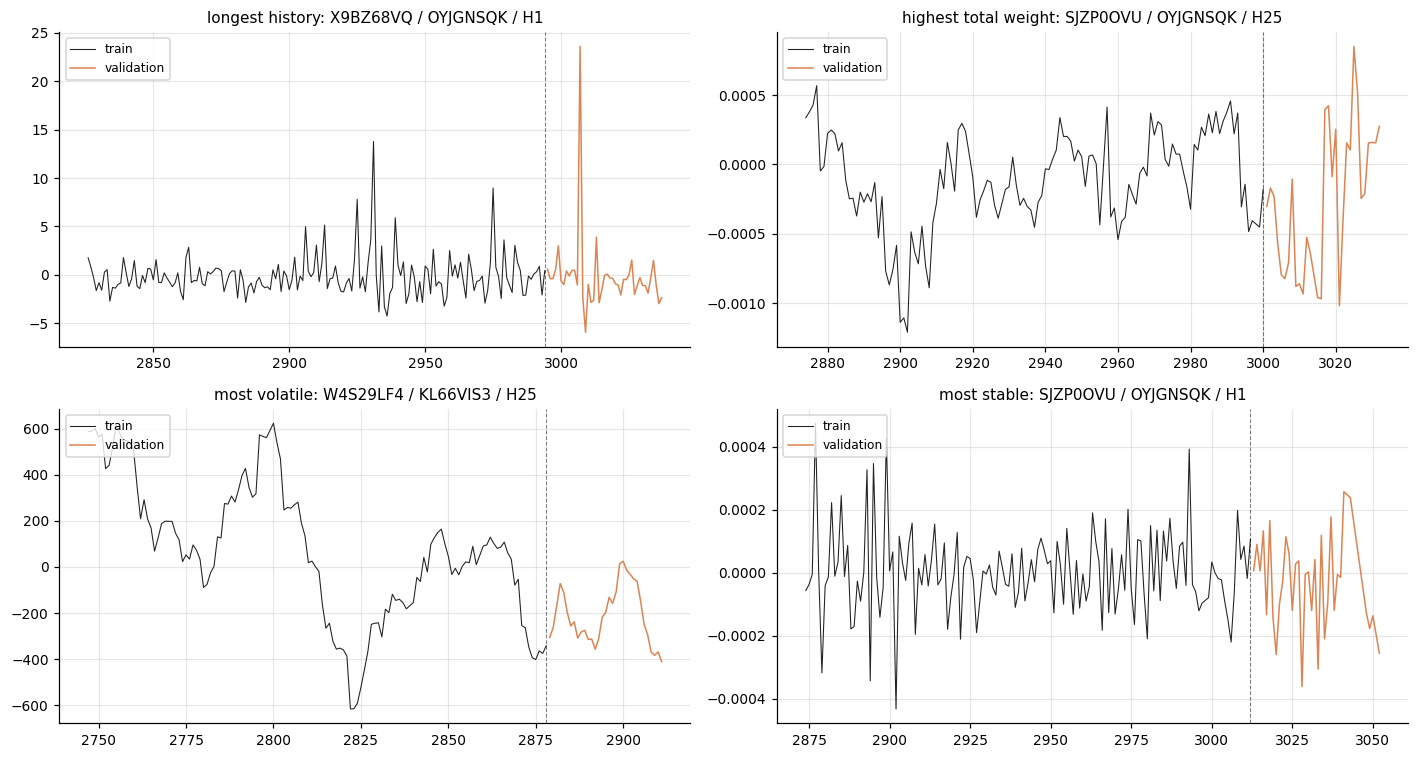

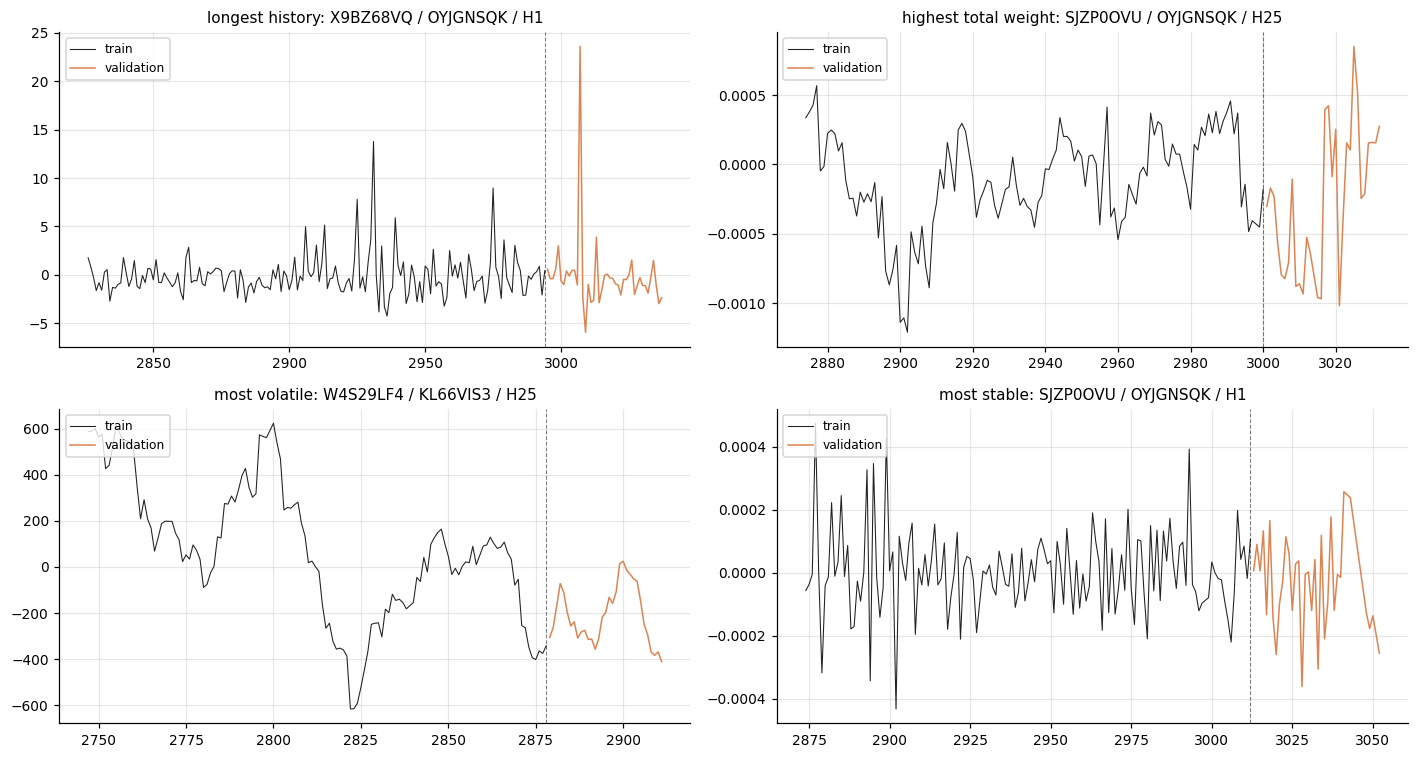

In [4]:
ordered_reasons = ['longest history', 'highest total weight', 'most volatile', 'most stable']

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
axes_flat = axes.flatten()
for ax, reason in zip(axes_flat, ordered_reasons):
    row, full_series, train_part, val_part = series_data[reason]
    ax.plot(train_part['ts_index'], train_part['y_target'], color=COLOR_TRAIN, lw=0.7, label='train')
    ax.plot(val_part['ts_index'],   val_part['y_target'],   color=COLOR_TRUTH, lw=1.0, label='validation')
    ax.axvline(train_part['ts_index'].iloc[-1], color='black', ls='--', lw=0.7, alpha=0.5)
    ax.set_title(f"{reason}: {row['code']} / {row['sub_code']} / H{int(row['horizon'])}", fontsize=10)
    ax.legend(fontsize=8, loc='upper left')
plt.tight_layout()
viz.save_figure(fig, '01_raw_series_overview', FIG_DIR)

**Reading.** The four panels operate at wildly different vertical scales (most-volatile swings between $-600$ and $+600$, most-stable occupies a range narrower than $0.0004$). Any single forecasting protocol has to handle all four regimes.


## 2. Model lineup

Four families plus naive baselines. AR / MA / ARMA / ARIMA orders are auto-selected per series by AICc on a small grid of $(p, q) \in \{0, 1, 2, 3\}^2$. Each forecaster stashes the selected order *and* the resulting AICc on the function object so the run loop can persist them.


In [5]:
# --- Naive baselines (no AICc concept) ---
def forecast_zero(y_train, steps):
    forecast_zero.last_order = None
    forecast_zero.last_aicc = None
    return np.zeros(steps)
forecast_zero.last_order = None
forecast_zero.last_aicc = None


def forecast_naive(y_train, steps):
    forecast_naive.last_order = None
    forecast_naive.last_aicc = None
    return np.repeat(float(y_train.iloc[-1]), steps)
forecast_naive.last_order = None
forecast_naive.last_aicc = None


def forecast_drift(y_train, steps):
    forecast_drift.last_order = None
    forecast_drift.last_aicc = None
    if len(y_train) < 2:
        return np.repeat(float(y_train.iloc[-1]), steps)
    slope = (y_train.iloc[-1] - y_train.iloc[0]) / (len(y_train) - 1)
    last = float(y_train.iloc[-1])
    return last + slope * np.arange(1, steps + 1)
forecast_drift.last_order = None
forecast_drift.last_aicc = None


# --- Smoothing family ---
def forecast_rolling_mean(y_train, steps, window=10):
    forecast_rolling_mean.last_order = None
    forecast_rolling_mean.last_aicc = None
    w = min(window, len(y_train))
    return np.repeat(float(y_train.iloc[-w:].mean()), steps)
forecast_rolling_mean.last_order = None
forecast_rolling_mean.last_aicc = None


def forecast_ses(y_train, steps):
    fit = SimpleExpSmoothing(y_train, initialization_method='estimated').fit(optimized=True)
    forecast_ses.last_order = None
    forecast_ses.last_aicc = float(fit.aicc) if hasattr(fit, 'aicc') and np.isfinite(fit.aicc) else None
    return np.asarray(fit.forecast(steps), dtype=float)
forecast_ses.last_order = None
forecast_ses.last_aicc = None


def forecast_holt(y_train, steps):
    fit = Holt(y_train, initialization_method='estimated').fit(optimized=True)
    forecast_holt.last_order = None
    forecast_holt.last_aicc = float(fit.aicc) if hasattr(fit, 'aicc') and np.isfinite(fit.aicc) else None
    return np.asarray(fit.forecast(steps), dtype=float)
forecast_holt.last_order = None
forecast_holt.last_aicc = None


# --- AICc helper ---
def aicc(fit_result, n):
    k = len(fit_result.params)
    if n - k - 1 <= 0:
        return np.inf
    return fit_result.aic + 2 * k * (k + 1) / (n - k - 1)


def make_constrained_arima_forecaster(d, restrict_q_zero=False, restrict_p_zero=False, family_name=''):
    def _forecast(y_train, steps):
        n = len(y_train)
        best_order, best_fit, best_aicc = None, None, np.inf
        p_range = [0] if restrict_p_zero else [0, 1, 2, 3]
        q_range = [0] if restrict_q_zero else [0, 1, 2, 3]
        for p in p_range:
            for q in q_range:
                if p == 0 and q == 0 and d == 0:
                    continue
                try:
                    fit = ARIMA(y_train, order=(p, d, q),
                                enforce_stationarity=False,
                                enforce_invertibility=False).fit()
                    a = aicc(fit, n)
                    if np.isfinite(a) and a < best_aicc:
                        best_aicc = a
                        best_order = (p, d, q)
                        best_fit = fit
                except Exception:
                    continue
        if best_fit is None:
            raise ValueError('no_fit')
        pred = np.asarray(best_fit.forecast(steps), dtype=float)
        if not np.all(np.isfinite(pred)):
            raise ValueError('non_finite_forecast')
        _forecast.last_order = best_order
        _forecast.last_aicc = float(best_aicc)
        return pred
    _forecast.__name__ = family_name
    _forecast.last_order = None
    _forecast.last_aicc = None
    return _forecast


MODEL_SPECS = {
    'Zero':              {'family': 'Naive',     'min_train': 1,  'func': forecast_zero},
    'Naive (lag-1)':     {'family': 'Naive',     'min_train': 1,  'func': forecast_naive},
    'Drift':             {'family': 'Naive',     'min_train': 2,  'func': forecast_drift},
    'Rolling Mean (w=10)':{'family': 'Smoothing','min_train': 2,  'func': forecast_rolling_mean},
    'SES':               {'family': 'Smoothing', 'min_train': 3,  'func': forecast_ses},
    'Holt':              {'family': 'Smoothing', 'min_train': 5,  'func': forecast_holt},
    'AR (auto)':         {'family': 'AR',        'min_train': 20,
                          'func': make_constrained_arima_forecaster(d=0, restrict_q_zero=True,  family_name='AR')},
    'MA (auto)':         {'family': 'MA',        'min_train': 20,
                          'func': make_constrained_arima_forecaster(d=0, restrict_p_zero=True,  family_name='MA')},
    'ARMA (auto)':       {'family': 'ARMA',      'min_train': 20,
                          'func': make_constrained_arima_forecaster(d=0, family_name='ARMA')},
    'ARIMA d=1 (auto)':  {'family': 'ARIMA',     'min_train': 20,
                          'func': make_constrained_arima_forecaster(d=1, family_name='ARIMA')},
}

lineup = pd.DataFrame([{'model': name, 'family': spec['family'], 'min_train': spec['min_train']}
                        for name, spec in MODEL_SPECS.items()])
lineup

,model,family,min_train
0,Zero,Naive,1
1,Naive (lag-1),Naive,1
2,Drift,Naive,2
3,Rolling Mean (w=10),Smoothing,2
4,SES,Smoothing,3
5,Holt,Smoothing,5
6,AR (auto),AR,20
7,MA (auto),MA,20
8,ARMA (auto),ARMA,20
9,ARIMA d=1 (auto),ARIMA,20


## 3. Run the full grid

Each model is fit on the per-series training segment and forecasts the whole validation segment in one closed-form multi-step pass. AICc is captured for every model that has one (smoothing-family SES and Holt, plus all ARIMA-family fits).


In [6]:
def fit_and_score(model_name, spec, y_train, y_val, w_val):
    if len(y_train) < spec['min_train']:
        return {'status': 'skipped',
                'skip_reason': f"train_len<{spec['min_train']}",
                'pred': None, 'order': None, 'aicc': None}
    try:
        pred = np.asarray(spec['func'](y_train, len(y_val)), dtype=float)
        if not np.all(np.isfinite(pred)):
            raise ValueError('non_finite_forecast')
    except Exception as exc:
        return {'status': 'failed',
                'skip_reason': type(exc).__name__,
                'pred': None, 'order': None, 'aicc': None}
    skill = metrics.weighted_skill_score(y_val, pred, w_val)
    rmse  = metrics.weighted_rmse(y_val, pred, w_val)
    order = getattr(spec['func'], 'last_order', None)
    a     = getattr(spec['func'], 'last_aicc', None)
    return {'status': 'ok', 'skip_reason': None,
            'pred': pred, 'order': order, 'aicc': a,
            'skill': skill, 'rmse': rmse}


results_rows = []
predictions = {}

for reason, (row, _, train_part, val_part) in series_data.items():
    y_train = train_part['y_target'].reset_index(drop=True)
    y_val = val_part['y_target'].to_numpy(dtype=float)
    w_val = val_part['weight'].to_numpy(dtype=float)
    for model_name, spec in MODEL_SPECS.items():
        res = fit_and_score(model_name, spec, y_train, y_val, w_val)
        results_rows.append({
            'reason': reason,
            'series_label': f"{row['code']}/{row['sub_code']}/H{int(row['horizon'])}",
            'model': model_name,
            'family': spec['family'],
            'order': str(res.get('order')) if res.get('order') else '-',
            'aicc': res.get('aicc'),
            'train_len': len(y_train),
            'val_len': len(y_val),
            'status': res['status'],
            'skip_reason': res['skip_reason'],
            'skill': res.get('skill', np.nan),
            'rmse': res.get('rmse', np.nan),
        })
        if res['status'] == 'ok':
            predictions[(reason, model_name)] = res['pred']

results_df = pd.DataFrame(results_rows)
print('Status counts:')
print(results_df['status'].value_counts())
results_df[['reason', 'model', 'family', 'order', 'aicc', 'status', 'skill', 'rmse']].round(4).head(20)

Status counts:
status
ok    40
Name: count, dtype: int64


,reason,model,family,order,aicc,status,skill,rmse
0,longest history,Zero,Naive,-,NaN,ok,0.0000,4.0190
1,longest history,Naive (lag-1),Naive,-,NaN,ok,0.0000,4.0575
2,longest history,Drift,Naive,-,NaN,ok,0.0000,4.0200
3,longest history,Rolling Mean (w=10),Smoothing,-,NaN,ok,0.0000,4.0293
4,longest history,SES,Smoothing,-,263.3615,ok,0.0335,4.0167
5,longest history,Holt,Smoothing,-,266.8978,ok,0.0000,4.0390
6,longest history,AR (auto),AR,"(3, 0, 0)",732.6019,ok,0.0422,4.0154
7,longest history,MA (auto),MA,"(0, 0, 3)",728.5628,ok,0.0408,4.0156
8,longest history,ARMA (auto),ARMA,"(3, 0, 3)",725.6695,ok,0.0000,4.0516
9,longest history,ARIMA d=1 (auto),ARIMA,"(2, 1, 3)",723.3299,ok,0.0000,4.0510


## 4. Per-series leaderboard with bootstrap CIs

Best model per series under weighted skill, with 95% bootstrap intervals from row resampling. The Naive (lag-1) skill is shown as the floor.


In [7]:
ok = results_df[results_df['status'] == 'ok'].copy()

best_rows = []
for reason, group in ok.groupby('reason', sort=False):
    best = group.sort_values('skill', ascending=False).iloc[0]
    naive = group[group['model'] == 'Naive (lag-1)'].iloc[0] if (group['model'] == 'Naive (lag-1)').any() else None
    row, _, _, val_part = series_data[reason]
    y_val = val_part['y_target'].to_numpy(dtype=float)
    w_val = val_part['weight'].to_numpy(dtype=float)
    pred = predictions[(reason, best['model'])]
    mean, lo, hi = metrics.bootstrap_skill(y_val, pred, w_val, n_boot=500, seed=SEED)
    best_rows.append({
        'reason': reason,
        'best_model': best['model'],
        'order': best['order'],
        'family': best['family'],
        'aicc': round(best['aicc'], 2) if best['aicc'] is not None and not pd.isna(best['aicc']) else None,
        'skill': round(best['skill'], 4),
        'skill_CI_lo': round(lo, 4),
        'skill_CI_hi': round(hi, 4),
        'naive_skill': round(naive['skill'], 4) if naive is not None else np.nan,
        'train_len': int(best['train_len']),
        'val_len': int(best['val_len']),
    })
leaderboard = pd.DataFrame(best_rows)
leaderboard

,reason,best_model,order,family,aicc,skill,skill_CI_lo,skill_CI_hi,naive_skill,train_len,val_len
0,longest history,AR (auto),"(3, 0, 0)",AR,732.60,0.0422,0.0000,0.2733,0.0000,169,43
1,highest total weight,SES,-,Smoothing,-2086.21,0.4669,0.0000,0.6487,0.4397,124,32
2,most volatile,Rolling Mean (w=10),-,Smoothing,NaN,0.8028,0.5592,0.9136,0.6713,129,33
3,most stable,Rolling Mean (w=10),-,Smoothing,NaN,0.1743,0.0000,0.2670,0.0000,136,34


## 4b. Per-series skill comparison

A horizontal bar chart of every model's weighted skill, one panel per series, sorted descending. The Naive (lag-1) bar is drawn in a contrasting colour so the floor is visually obvious. This shows *within* a series how close models cluster --- the within-series ranking is more informative than the cross-series mean.


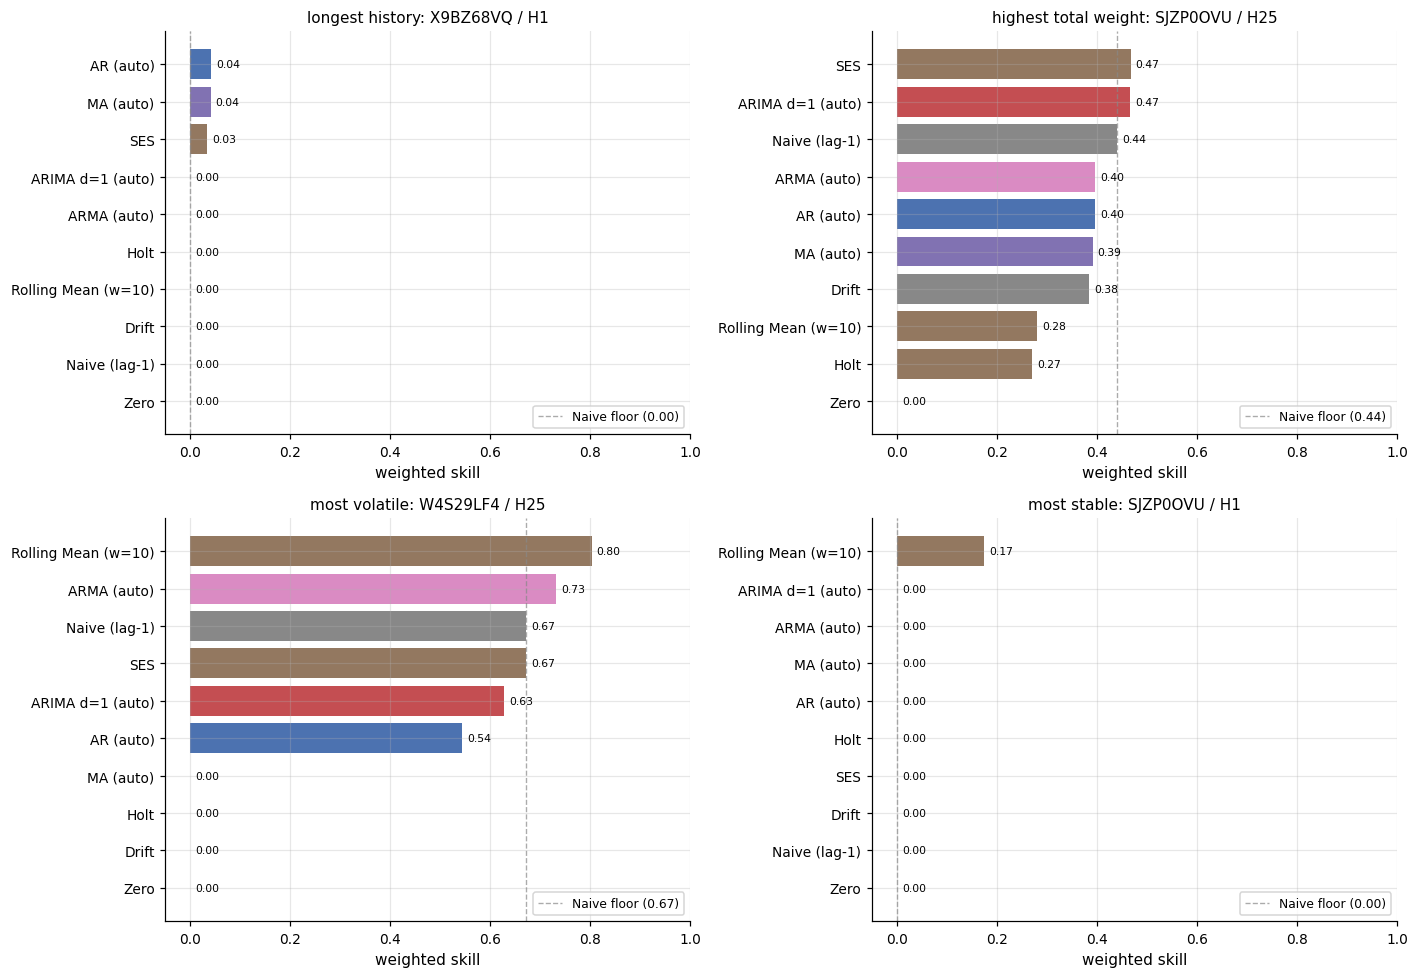

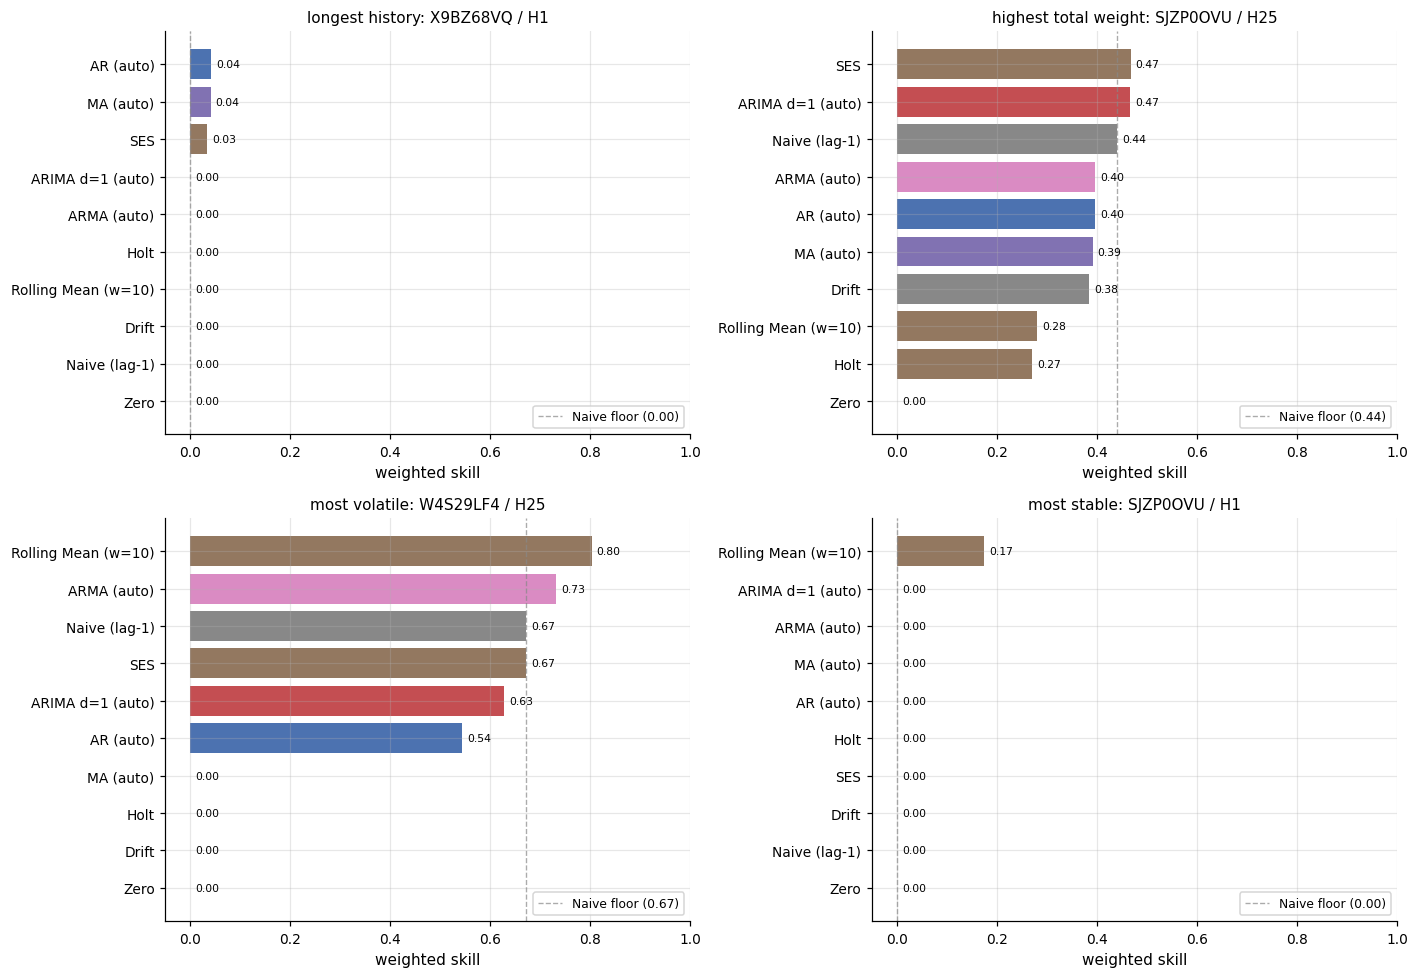

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes_flat = axes.flatten()
for ax, reason in zip(axes_flat, ordered_reasons):
    row, _, _, _ = series_data[reason]
    g = ok[ok['reason'] == reason].copy()
    g = g.sort_values('skill', ascending=True)
    colors = []
    for _, r in g.iterrows():
        if r['model'] == 'Naive (lag-1)':
            colors.append(COLOR_NAIVE)
        else:
            colors.append(FAMILY_COLORS.get(r['family'], '#cccccc'))
    bars = ax.barh(g['model'], g['skill'], color=colors)
    naive_skill = g[g['model'] == 'Naive (lag-1)']['skill'].iloc[0] if (g['model'] == 'Naive (lag-1)').any() else 0.0
    ax.axvline(naive_skill, color=COLOR_NAIVE, ls='--', lw=0.9, alpha=0.7,
               label=f'Naive floor ({naive_skill:.2f})')
    for bar, val in zip(bars, g['skill']):
        ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                f'{val:.2f}', va='center', fontsize=7)
    ax.set_xlim(-0.05, max(1.0, g['skill'].max() * 1.15))
    ax.set_xlabel('weighted skill')
    ax.set_title(f"{reason}: {row['code']} / H{int(row['horizon'])}", fontsize=10)
    ax.legend(fontsize=8, loc='lower right')
plt.tight_layout()
viz.save_figure(fig, '01_per_series_skill_bars', FIG_DIR)

**Reading.** Two patterns to note. First, the within-series ranking is what matters; the four panels' x-axis ranges differ wildly because the underlying data does. Second, on three of four series the gap between the top model and the naive floor is small --- consistent with the bootstrap intervals in the leaderboard table.


## 5. Skip-status table

Under adaptive splits every series clears the 20-row minimum-training-length gate, so the ARMA/ARIMA fits that the midway had to skip under the fixed cutoff all run here.


In [9]:
skipped = results_df[results_df['status'] != 'ok']
if len(skipped) == 0:
    print('No fits skipped under adaptive splits.')
else:
    skipped[['reason', 'model', 'family', 'train_len', 'status', 'skip_reason']]

No fits skipped under adaptive splits.


## 6. Forecast overlays --- 2x2 grid (best model + Naive floor + open-loop one-step)

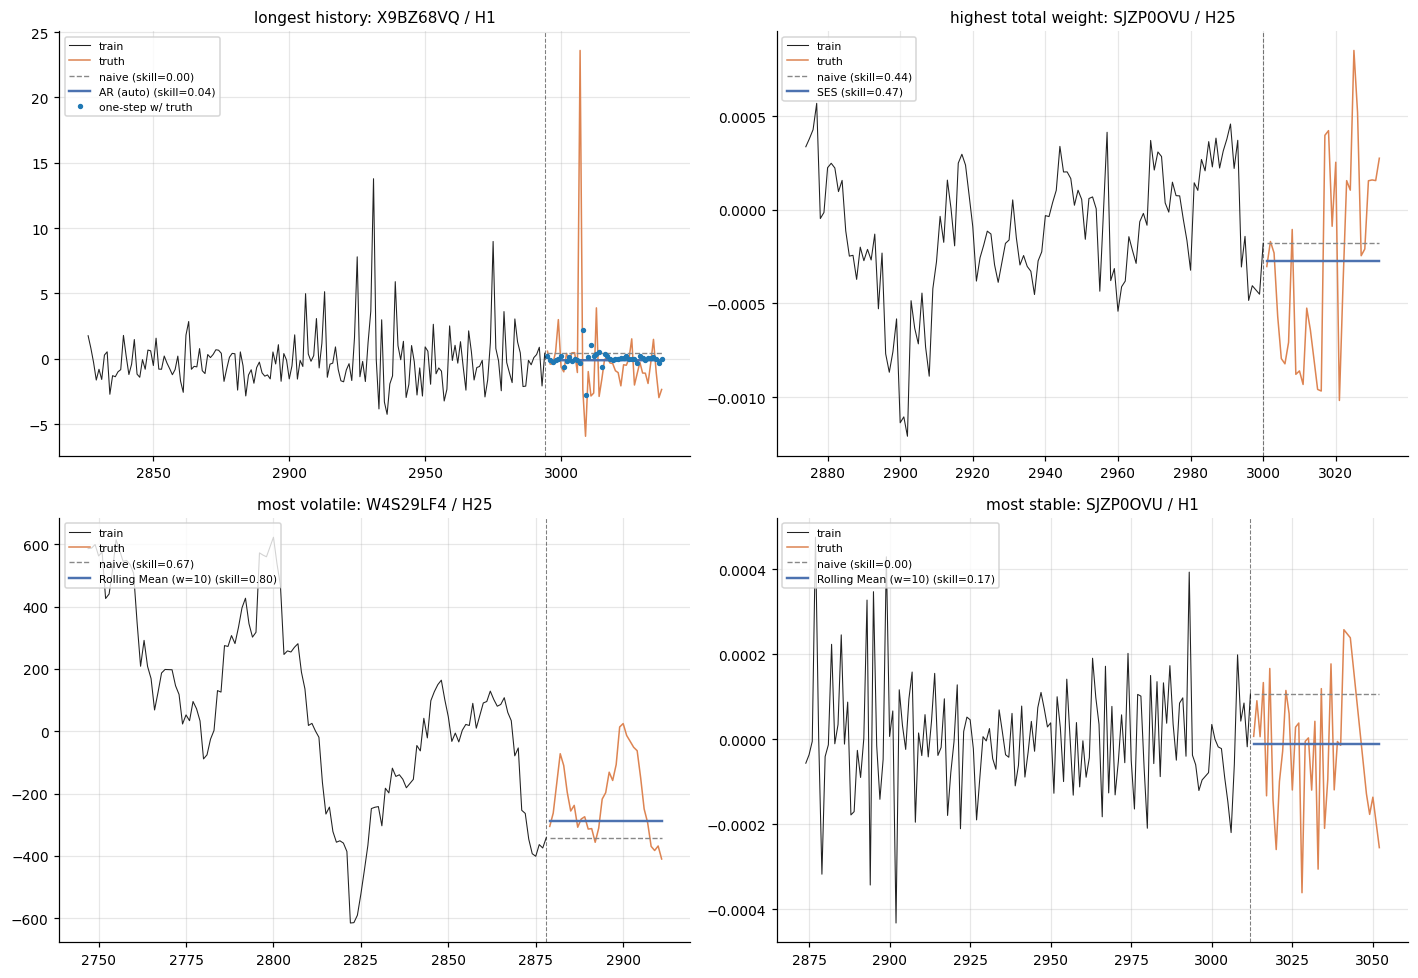

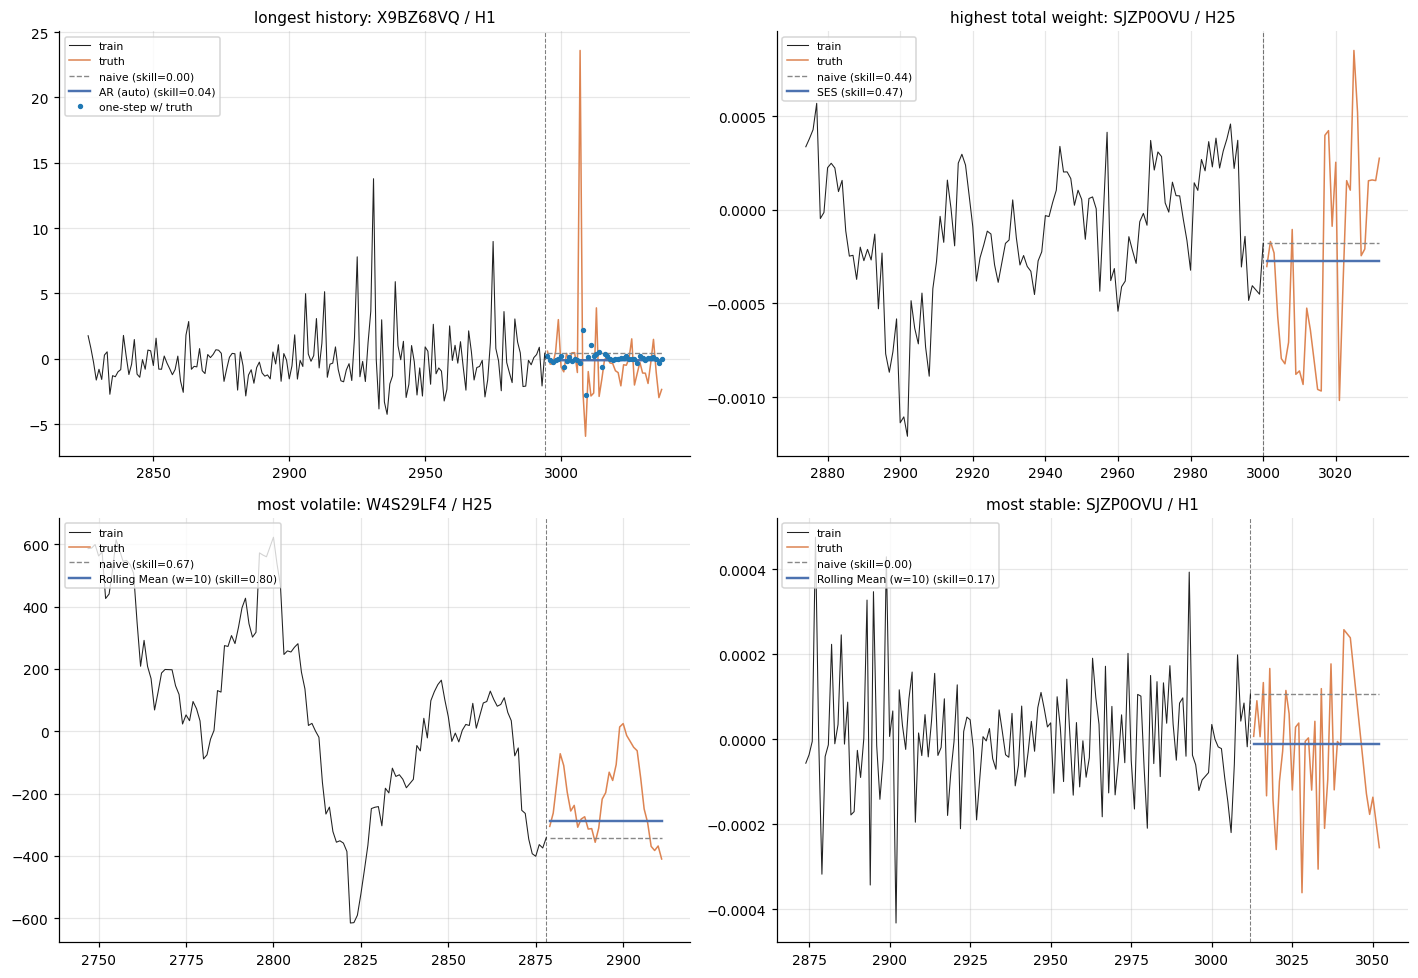

In [10]:
def open_loop_one_step(model_func, y_train, y_val):
    y_history = list(np.asarray(y_train, dtype=float))
    preds = []
    for v in y_val:
        try:
            p = model_func(pd.Series(y_history), 1)
            preds.append(float(p[0]))
        except Exception:
            preds.append(np.nan)
        y_history.append(float(v))
    return np.asarray(preds)


fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes_flat = axes.flatten()

for ax, reason in zip(axes_flat, ordered_reasons):
    row, full_series, train_part, val_part = series_data[reason]
    y_train = train_part['y_target'].reset_index(drop=True)
    y_val = val_part['y_target'].to_numpy(dtype=float)
    cutoff_ts = train_part['ts_index'].iloc[-1]
    best = leaderboard[leaderboard['reason'] == reason].iloc[0]
    best_pred_a = predictions[(reason, best['best_model'])]
    naive_pred = predictions[(reason, 'Naive (lag-1)')]

    ax.plot(train_part['ts_index'], train_part['y_target'], color=COLOR_TRAIN, lw=0.7, label='train')
    ax.plot(val_part['ts_index'],   val_part['y_target'],   color=COLOR_TRUTH, lw=1.0, label='truth')
    ax.plot(val_part['ts_index'], naive_pred, color=COLOR_NAIVE, ls='--', lw=0.9,
            label=f"naive (skill={best['naive_skill']:.2f})")
    ax.plot(val_part['ts_index'], best_pred_a, color=COLOR_BEST, lw=1.6,
            label=f"{best['best_model']} (skill={best['skill']:.2f})")

    spec = MODEL_SPECS[best['best_model']]
    if best['family'] in ('AR', 'ARMA', 'ARIMA'):
        try:
            best_pred_c = open_loop_one_step(spec['func'], y_train, y_val)
            ax.plot(val_part['ts_index'], best_pred_c, color=COLOR_BEST_C,
                    marker='o', ms=2.5, lw=0, label='one-step w/ truth')
        except Exception:
            pass

    ax.axvline(cutoff_ts, color='black', ls='--', lw=0.7, alpha=0.5)
    ax.set_title(f"{reason}: {row['code']} / H{int(row['horizon'])}", fontsize=10)
    ax.legend(fontsize=7, loc='upper left')

plt.tight_layout()
viz.save_figure(fig, '01_forecast_overlay_2x2', FIG_DIR)

## 6b. Family-comparison forecast overlays

Instead of just the *best* model per series, this figure shows the best model from *each* family on the same axes. Lets you see how AR, MA, ARMA, ARIMA, SES, and Holt actually look as forecasts on each series, beyond which one happens to win.


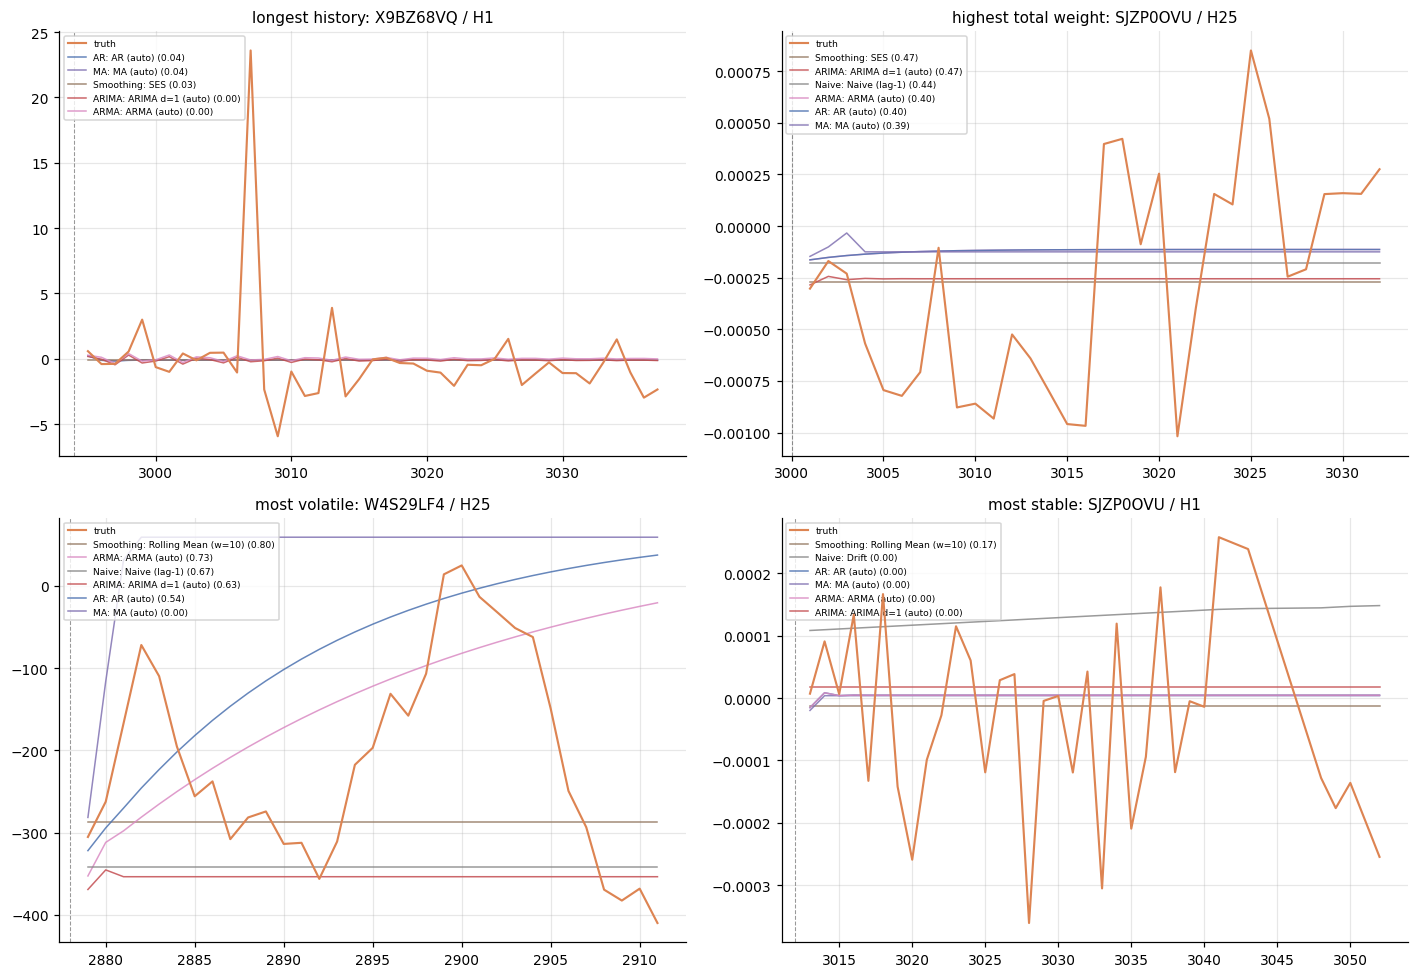

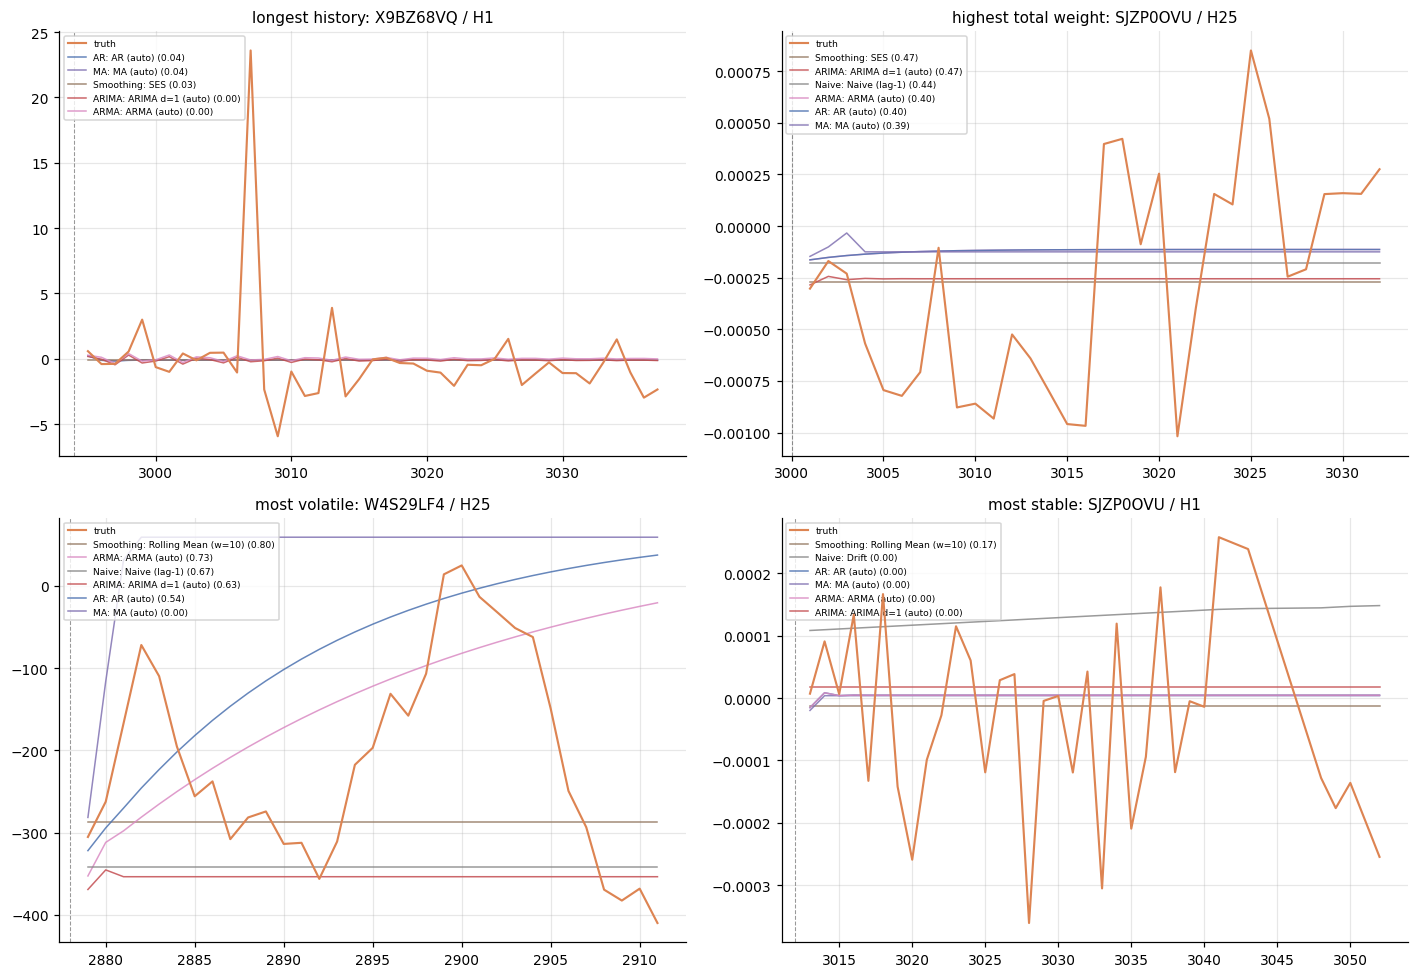

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes_flat = axes.flatten()

# Pick best model per (reason, family) by skill
best_per_family = (
    ok.sort_values('skill', ascending=False)
      .groupby(['reason', 'family'], sort=False).head(1)
      .copy()
)

for ax, reason in zip(axes_flat, ordered_reasons):
    row, full_series, train_part, val_part = series_data[reason]
    cutoff_ts = train_part['ts_index'].iloc[-1]

    # Plot only validation segment for clarity
    ax.plot(val_part['ts_index'], val_part['y_target'], color=COLOR_TRUTH, lw=1.4, label='truth', zorder=10)

    fam_subset = best_per_family[best_per_family['reason'] == reason]
    for _, fam_row in fam_subset.iterrows():
        family = fam_row['family']
        model = fam_row['model']
        # Skip the Naive Zero, Naive lag-1, Drift to keep the chart readable
        if model in ('Zero',):
            continue
        if (reason, model) not in predictions:
            continue
        pred = predictions[(reason, model)]
        ax.plot(val_part['ts_index'], pred,
                color=FAMILY_COLORS.get(family, '#cccccc'), lw=1.0, alpha=0.85,
                label=f"{family}: {model} ({fam_row['skill']:.2f})")

    ax.axvline(cutoff_ts, color='black', ls='--', lw=0.7, alpha=0.4)
    ax.set_title(f"{reason}: {row['code']} / H{int(row['horizon'])}", fontsize=10)
    ax.legend(fontsize=6, loc='upper left', ncol=1)

plt.tight_layout()
viz.save_figure(fig, '01_family_comparison_overlay', FIG_DIR)

**Reading.** Three things stand out across the four panels.

- The smoothing family produces flat or near-flat forecasts because their multi-step formula is constant after the cutoff. The AR / MA / ARMA / ARIMA families produce more dynamic forecasts but they often drift away from the truth as the horizon grows.
- On the most-volatile series the dynamic models track the true trajectory better than smoothing in the first few validation steps, then degrade. This is the multi-step error compounding effect.
- On the most-stable series every family produces forecasts close to zero. The series itself has little signal, so model choice has little leverage.


## 6c. Best-model absolute error over time

For each series, the absolute prediction error of the winning model across the validation window. Reveals whether errors are uniform across the window or concentrated on a few high-impact rows --- which matters for the weighted skill score because high-weight rows count more.


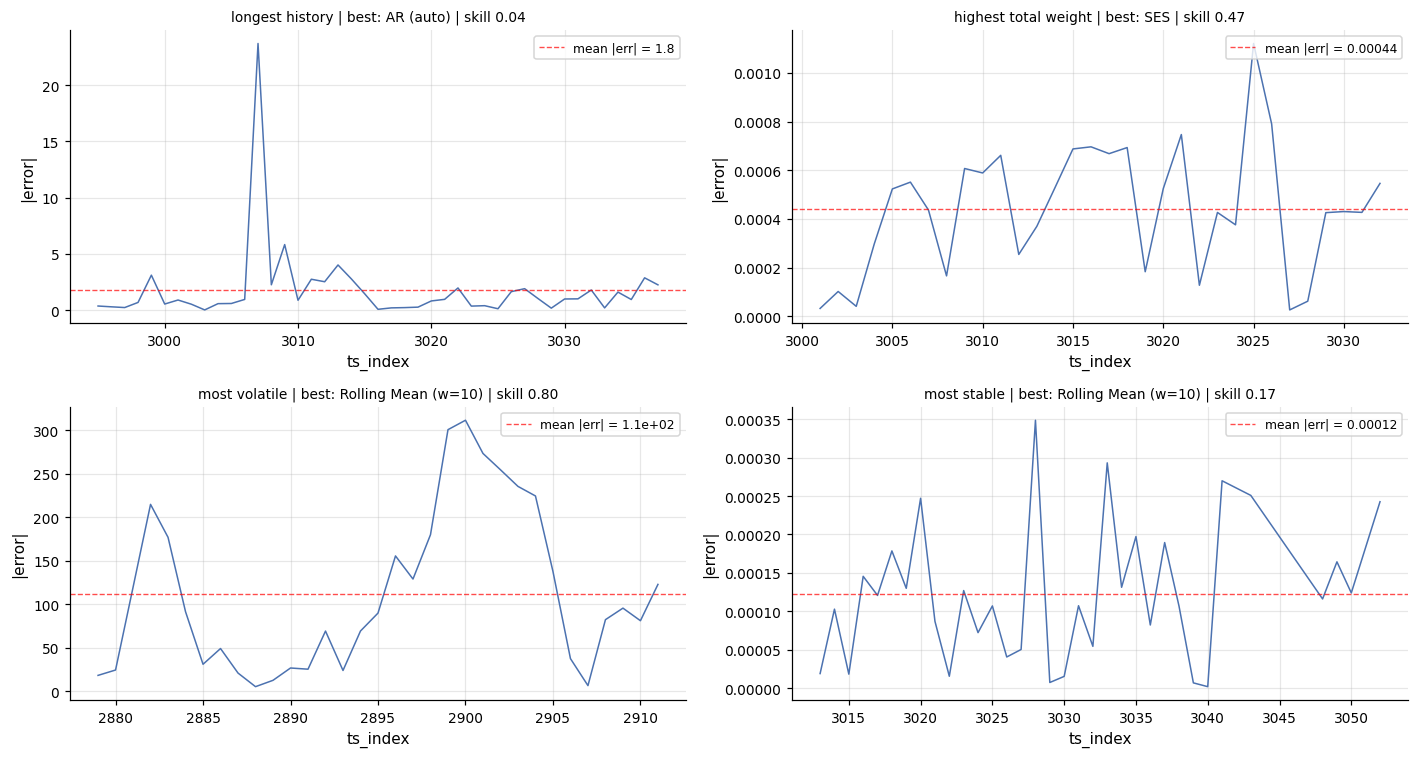

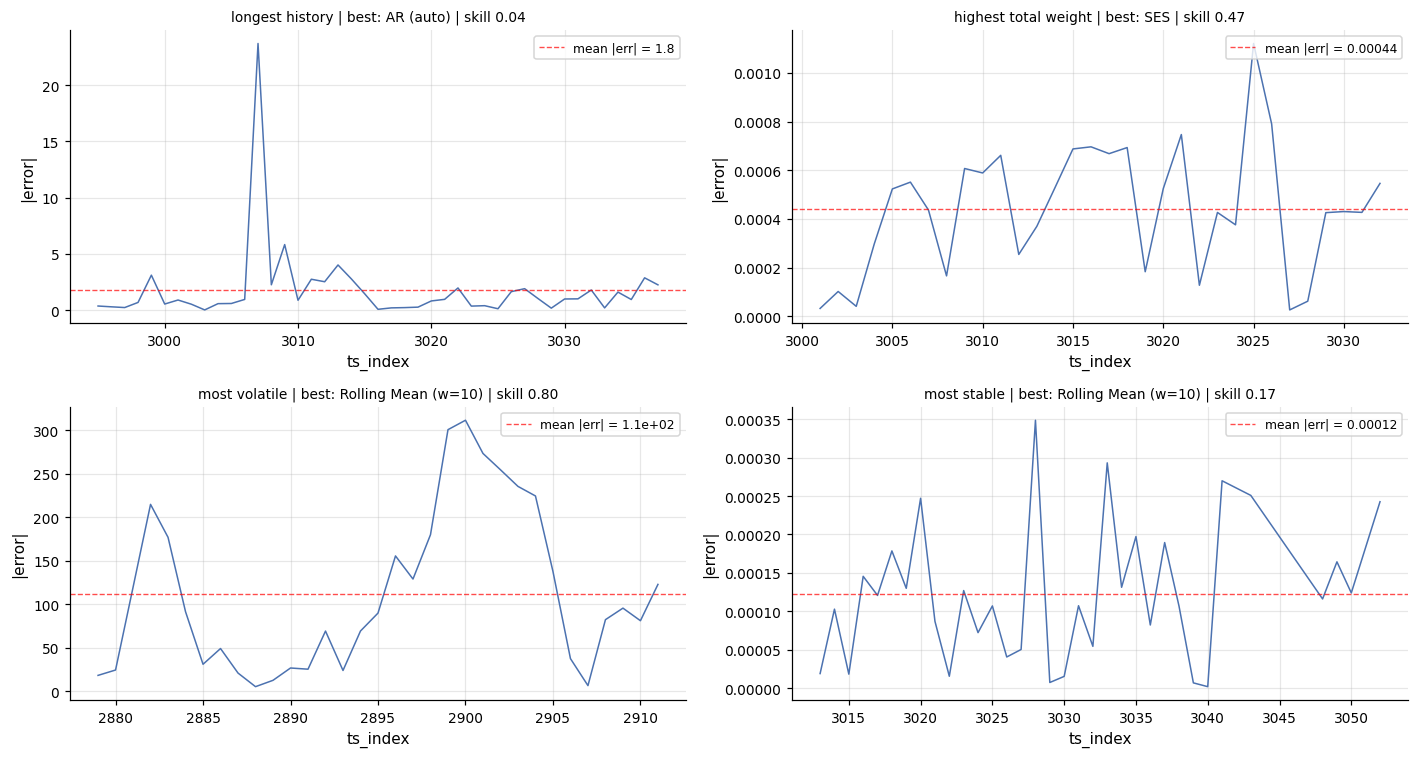

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
axes_flat = axes.flatten()
for ax, reason in zip(axes_flat, ordered_reasons):
    row, _, train_part, val_part = series_data[reason]
    best = leaderboard[leaderboard['reason'] == reason].iloc[0]
    best_pred = predictions[(reason, best['best_model'])]
    truth = val_part['y_target'].to_numpy(dtype=float)
    err = np.abs(truth - best_pred)
    mean_err = err.mean()
    ax.plot(val_part['ts_index'], err, color=COLOR_BEST, lw=1.0)
    ax.axhline(mean_err, color='red', ls='--', lw=0.9, alpha=0.7,
               label=f'mean |err| = {mean_err:.2g}')
    ax.set_title(f"{reason} | best: {best['best_model']} | skill {best['skill']:.2f}", fontsize=9)
    ax.set_ylabel('|error|')
    ax.set_xlabel('ts_index')
    ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
viz.save_figure(fig, '01_best_model_error_over_time', FIG_DIR)

**Reading.** On the most-volatile series the error is bumpy but bounded; the rolling-mean forecast tracks the broad trajectory and misses on local swings. On the longest-history series the error spikes occasionally where the truth has rare large jumps --- this is the heavy-tail phenomenon from §4.4 of the EDA. On the highest-weight and most-stable series the absolute errors are numerically tiny but matter under the weighted score because of the upweighting of those rows.


## 7. Save artifacts

In [13]:
io.save_processed(results_df, 'classical_per_series_results')
io.save_processed(leaderboard, 'classical_leaderboard')

pred_rows = []
for (reason, model_name), pred in predictions.items():
    val_ts = series_data[reason][3]['ts_index'].to_numpy()
    for ts, p in zip(val_ts, pred):
        pred_rows.append({'reason': reason, 'model': model_name,
                          'ts_index': int(ts), 'pred': float(p)})
predictions_df = pd.DataFrame(pred_rows)
io.save_processed(predictions_df, 'classical_predictions')

print('Saved:')
for name in ['classical_per_series_results', 'classical_leaderboard', 'classical_predictions']:
    p = io.PROCESSED_DIR / f'{name}.parquet'
    print(f'  {p.name}: {p.stat().st_size:,} bytes')

Saved:
  classical_per_series_results.parquet: 8,132 bytes
  classical_leaderboard.parquet: 6,908 bytes
  classical_predictions.parquet: 9,838 bytes


## 8. What this study can and cannot say

1. **Per-series classical fits are bounded by training length and target structure, not by model sophistication.**
2. **The volatile series is the one positive case.** Rolling Mean (w=10) wins because the panel ACF in the EDA showed persistent low-order lags --- a simple recent-window average captures the dominant short-memory signal without overfitting.
3. **Per-series fitting throws away the global panel structure.** The 86 anonymised features and the cross-series correlations are entirely unused here. Notebook 02 uses both.

## 9. Viva cheat sheet

1. **Why adaptive splits.** The canonical fixed cutoff at `ts_index = 2880` leaves the highest-weight and most-stable series with 7 training rows, below the 20-row minimum for ARMA/ARIMA.
2. **Why AICc auto-selection.** Hand-picking from a grid of 12 orders inflates the multiple-comparisons risk. AICc selects one order per series per family using a small-sample-corrected information criterion.
3. **Why AICc not AIC.** Burnham–Anderson recommend AICc whenever $n/k < 40$. Our $n/k$ ranges between 15 and 21, well inside the AICc regime.
4. **Why Naive (lag-1) is in every leaderboard.** It is the floor every other model has to clear.
5. **What "open-loop one-step" means.** At each validation step, the model is given the *true* previous value rather than its own previous prediction. The gap between this and the closed-form multi-step forecast measures the value of feedback at inference.
6. **Why three families lose on three of four series.** Target scale ~$10^{-4}$ on two series means weighted RMSE punishes any non-zero prediction, and the most-stable series has no exploitable signal in lag structure.
7. **Why this section motivates the global ML notebook.** Per-series local fits cannot use cross-series structure or the 86 features.
